# Базовый анализ данных и обработка информаций

In [1]:
import pandas as pd
import numpy as np
import os.path as path
import matplotlib.pyplot as plt

# Для изменения traceback
from IPython.core.ultratb import AutoFormattedTB

# Функция отлова ошибок(взято со StackOverFlow)

In [2]:
from IPython.core.ultratb import AutoFormattedTB

# Инициализация форматтера для преобразования сложных объектов ошибок в простой текст
itb = AutoFormattedTB(mode='Plain', tb_offset=1)

def custom_exc(shell, etype, evalue, tb, tb_offset=None):
    """
    Кастомный обработчик исключений для среды IPython/Jupyter.
    
    shell     - Экземпляр InteractiveShell (текущая сессия ноутбука). 
                Позволяет управлять выводом и доступом к ядру.
    etype     - Exception Type: Класс возникшей ошибки (например, FileNotFoundError).
    evalue    - Exception Value: Объект ошибки, содержащий сообщение (текст ошибки).
    tb        - Traceback: Стек вызовов, хранящий информацию о месте возникновения ошибки.
    tb_offset - Смещение стека: Количество верхних уровней вызова, которые нужно 
                скрыть (используется, чтобы не показывать системные механизмы обработки).
    """
    
    # Отображаем стандартное графическое уведомление об ошибке в Jupyter
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)

    # Формируем текстовую версию ошибки (без цветового оформления)
    stb = itb.structured_traceback(etype, evalue, tb)
    sstb = itb.stb2text(stb)

    # Выводим визуальный разделитель для явного уведомления пользователя
    print("\n" + "─"*50)
    print("КРИТИЧЕСКАЯ ОШИБКА: ОБРАБОТКА ПРЕРВАНА")
    print("─"*50)
    # Здесь можно добавить логирование переменной sstb в файл, если потребуется

# Регистрация функции как глобального обработчика для всех исключений типа Exception
get_ipython().set_custom_exc((Exception,), custom_exc)

In [3]:
BASEPATH = ".."
RESOURCES = f"{BASEPATH}/Resource"

# Импорт базы данных

In [4]:
if (not path.isdir(RESOURCES)):
    raise NotADirectoryError("Путь с Resouces не существует пожалуйста выполните 'git pull' или создайте папку так же загрузите kaddle поддробнее в README.md")
    
if (not path.isfile(f"{RESOURCES}/lenta-ru-news.csv")):
    raise FileNotFoundError("Файл для анализа и обучения моделей не существует пожайлуйста установите файл из kaddle подробнее в README.md")

In [5]:

try:
    DataBase = pd.read_csv(f"{RESOURCES}/lenta-ru-news.csv", low_memory=False)
    if (not DataBase.empty):
        print("─"*50)
        print("База данных инициализирована".center(50))
        print("─"*50)

except Exception as e:
    raise (f"Ошибка при загрузке базы данных: {e}")

──────────────────────────────────────────────────
           База данных инициализирована           
──────────────────────────────────────────────────


# Собираем информацию о базе данных

In [29]:
DataBase.head(10)

,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека,Первая мировая,1914/09/18
5,https://lenta.ru/news/1999/08/31/stancia_mir/,"Космонавты сомневаются в надежности ""Мира""",Как стало известно агентству Ассошиэйтед Пресс...,Россия,Все,1999/08/31
6,https://lenta.ru/news/1999/08/31/vzriv/,Взрыв в центре Москвы: пострадало 30 человек,В зале игровых автоматов в третьем ярусе подзе...,Россия,Все,1999/08/31
7,https://lenta.ru/news/1999/08/31/credit_japs/,Япония кредитует Россию на полтора миллиарда д...,Япония приняла решение разморозить кредиты Рос...,Россия,Все,1999/08/31
8,https://lenta.ru/news/1999/08/31/diana/,Британцы отмечают двухлетие смерти Дианы,Британцы отмечают сегодня скорбную дату - втор...,Мир,Все,1999/08/31
9,https://lenta.ru/news/1999/08/31/mvf/,Отмытые через Bank of NY деньги не имели отнош...,В понедельник директор департамента внешних св...,Россия,Все,1999/08/31


In [30]:
DataBase.describe()

,url,title,text,topic,tags,date
count,800975,800975,800970,738973,773756,800975
unique,800964,797832,800037,23,94,7393
top,https://lenta.ru/news/1999/10/21/y2k/,В Москве объявлено штормовое предупреждение,"РИА ""Новости""",Россия,Все,2019/12/05
freq,2,21,291,160445,453762,284


topic            
Россия               160445
Мир                  136621
Экономика             79528
Спорт                 64413
Культура              53797
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44663
Из жизни              27605
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
Сочи                      1
МедНовости                1
Name: count, dtype: int64

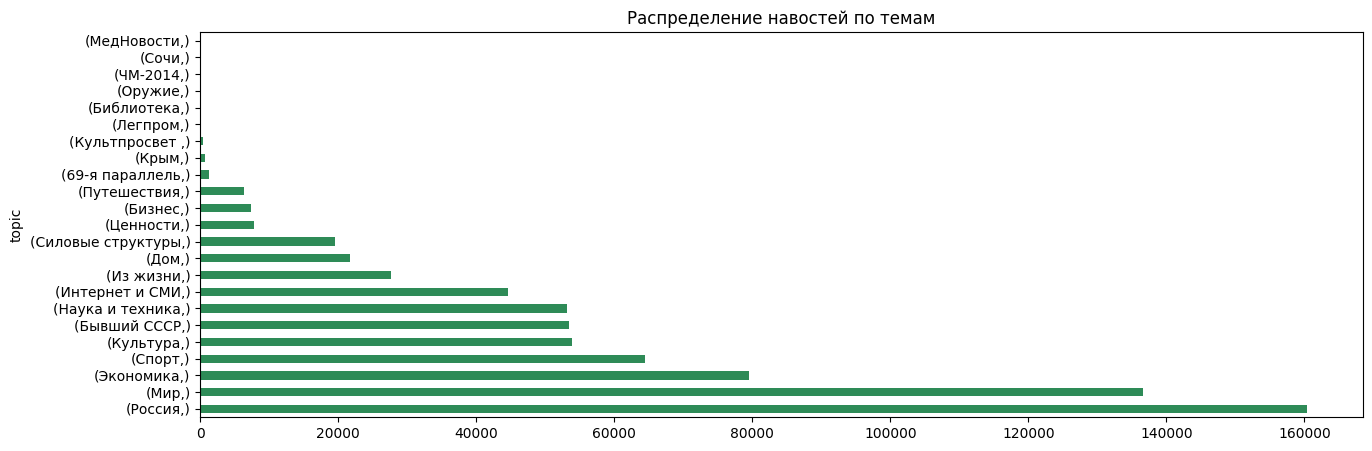

In [ ]:
DataBase[['topic']].value_counts().plot(kind='barh',figsize=(15,5), title="Распределение навостей по темам",color='seagreen')
DataBase[['topic']].value_counts()

tags
Все                453762
Политика            40716
Общество            35202
Украина             22523
Происшествия        19825
Госэкономика        15476
Футбол              15239
Кино                10720
Интернет             9319
Бизнес               9146
Следствие и суд      9133
Наука                7932
Музыка               7406
Люди                 6567
Квартира             5180
Name: count, dtype: int64

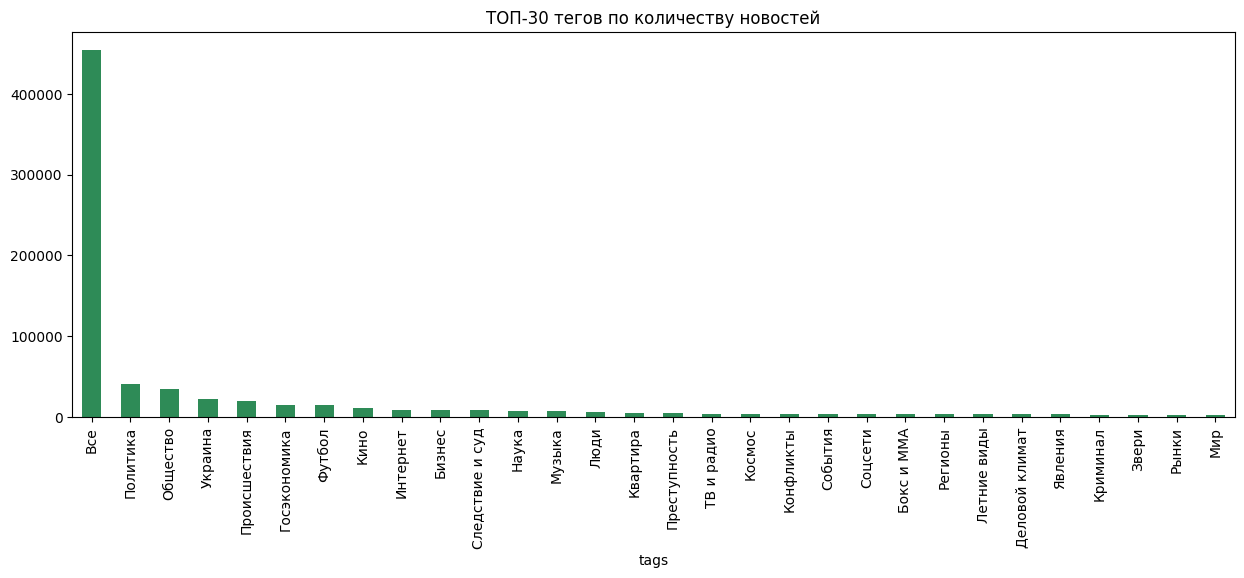

In [ ]:
DataBase['tags'].value_counts().head(30).plot(
    kind='bar', 
    figsize=(15, 5), 
    title="ТОП-30 тегов по количеству новостей", 
    color='seagreen'
)
DataBase['tags'].value_counts().head(15)

# Итог базового иследования базы данных
<div style="padding: 20px; border: 1px solid #238b46; border-radius: 15px; font-family: sans-serif; background-color: white; line-height: 1.5;">
<h2 style="color: #238b46; margin-top: 0; border-bottom: 2px solid #238b46; padding-bottom: 10px;">Анализ структуры данных (800 975 записей)</h2>
<p style="font-size: 1.1em; color: #444;">База представляет собой массив новостей за <b>20 лет</b>. Данные достаточно чистые, но имеют свои особенности:</p>
<table style="width: 100%; border-collapse: collapse; margin-bottom: 20px; color: black;">
<thead>
<tr style="background-color: #238b46; color: white;">
<th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Параметр</th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Что это значит для нас?</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f9f9f9;"><b>Объем (Count)</b></td>
<td style="padding: 10px; border: 1px solid #ddd;">В базе более <b>800 тысяч</b> статей. Это огромный датасет, подходящий для серьезного машинного обучения.</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Пропуски</b></td>
<td style="padding: 10px; border: 1px solid #ddd;">Почти отсутствуют в заголовках и текстах. Однако около <b>60-70 тысяч</b> новостей не имеют тегов или рубрик.</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f9f9f9;"><b>Темы (Topic)</b></td>
<td style="padding: 10px; border: 1px solid #ddd;">Всего <b>23 уникальные темы</b>. Самая частая — «Россия» (160к). Это удобная целевая переменная.</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Теги (Tags)</b></td>
<td style="padding: 10px; border: 1px solid #ddd;">Их 94 типа. Самый частый — «Все» (453к), который является «мусорным» тегом-заглушкой.</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f9f9f9;"><b>Временной охват</b></td>
<td style="padding: 10px; border: 1px solid #ddd;"><b>7393 дня</b> (~20 лет). Пиковая активность зафиксирована в декабре 2019 года.</td>
</tr>
</tbody>
</table>
</div>